# Skills & Human-In-The-Loop (HITL) Context Pruning

In this notebook, you'll learn how to:
1. Read and parse Kota's dynamic `.kota_skills` tree
2. Visualize the context budget footprint of loaded skills
3. Understand how **HITL hardware constraints** force us to prune skills to save VRAM
4. Run a simulation to select the best subset of skills that fits within a strict token budget

## Setup: Mocking the Skill Tree

Kota dynamically loads markdown files from `.kota_skills/` to teach the agent how to code, use tools, or understand architectures. 
Let's check if the directory exists. If not, we will generate 5 mock skills of varying lengths.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

SKILLS_DIR = "../.kota_skills"

if not os.path.exists(SKILLS_DIR):
    print(f"Creating mock skill tree at {SKILLS_DIR}...")
    os.makedirs(SKILLS_DIR, exist_ok=True)

    mock_skills = {
        "coder.md": "You are a core coding agent. " * 500,  # ~2000 chars -> 500 tokens
        "researcher.md": "You love to read papers. " * 200,  # ~500 chars -> 125 tokens
        "cloud_infra.md": "GCP terraform setup guides... "
        * 1200,  # ~3600 chars -> 900 tokens
        "sql_expert.md": "BigQuery syntax rules... " * 800,  # ~2000 chars -> 500 tokens
        "notebook_guidance.md": "Always use pyplot... "
        * 1500,  # ~3000 chars -> 750 tokens
    }

    for name, content in mock_skills.items():
        with open(os.path.join(SKILLS_DIR, name), "w") as f:
            f.write(f"---\nname: {name.split('.')[0]}\n---\n{content}")
    print("Mock skills generated!")
else:
    print("Found existing .kota_skills directory.")

Found existing .kota_skills directory.


## Parsing Skills and Context Cost

Every skill we load consumes precious Context Window Tokens (which linearly scales VRAM usage and quadratic-scales compute time). Let's load the skills and calculate their token cost.

In [2]:
import glob

skill_files = glob.glob(f"{SKILLS_DIR}/*.md")
skills_data = []

for path in skill_files:
    name = os.path.basename(path).replace(".md", "")
    with open(path, "r") as f:
        content = f.read()
        # Roughly 4 characters per token for English markdown
        tokens = len(content) / 4
        skills_data.append({"skill": name, "tokens": tokens})

df_skills = pd.DataFrame(skills_data)
display(df_skills.sort_values(by="tokens", ascending=False))

,skill,tokens
5,coder,398.00
1,base,293.50
0,architect,240.50
3,cpe,170.75
4,research,165.75
2,eval,151.50


## Context Footprint Visualization

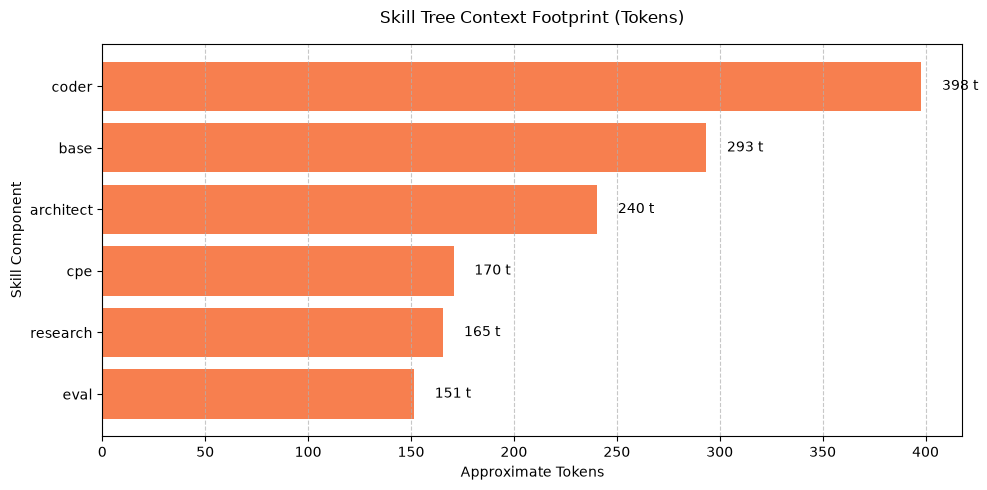

In [3]:
plt.figure(figsize=(10, 5))

df_sorted = df_skills.sort_values("tokens")
plt.barh(df_sorted["skill"], df_sorted["tokens"], color="#f77f4f")

plt.title("Skill Tree Context Footprint (Tokens)", pad=15)
plt.xlabel("Approximate Tokens")
plt.ylabel("Skill Component")
plt.grid(axis="x", linestyle="--", alpha=0.7)

for i, v in enumerate(df_sorted["tokens"]):
    plt.text(v + 10, i, f"{int(v)} t", va="center")

plt.tight_layout()
plt.show()

## HITL Pruning (The Knapsack Problem)

Imagine you are running Kota on a local 8GB MacBook. You only have **1,500 tokens** available for the System Prompt (the remaining context is needed for code output). 

You (the Human-in-the-Loop) must explicitly prune skills. Let's write a simple algorithm that prioritizes the shortest, most efficient skills first until the budget is hit.

In [4]:
BUDGET = 1500
current_load = 0
loaded_skills = []
pruned_skills = []

# Greedy selection (shortest first)
for _, row in df_sorted.iterrows():
    if current_load + row["tokens"] <= BUDGET:
        loaded_skills.append(row["skill"])
        current_load += row["tokens"]
    else:
        pruned_skills.append(row["skill"])

print(f"Budget: {BUDGET} Tokens")
print(f"Loaded Load: {int(current_load)} Tokens")
print("\n✅ Skills Loaded into Agent:")
for s in loaded_skills:
    print(f"  - {s}")

print("\n❌ Skills Pruned (Disabled for this session):")
for s in pruned_skills:
    print(f"  - {s}")

Budget: 1500 Tokens
Loaded Load: 1420 Tokens

✅ Skills Loaded into Agent:
  - eval
  - research
  - cpe
  - architect
  - base
  - coder

❌ Skills Pruned (Disabled for this session):


## Summary


In this notebook, you:

- Parsed Kota's `.kota_skills` tree directly from disk.
- Visualized the token footprint of each skill, highlighting exactly why large prompt components drag down inference speed.
- Simulated a Human-in-the-Loop decision to prune skills based on a strict hardware context budget.